# AES-T600 data set

## Import libraries

In [1]:
# %reset
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from pyts.image import GramianAngularField
import cv2


## Prameters

In [2]:
num_epochs = 40
sample_numbers = 10000
im_size=50
data_name ='T500'

## Paths

In [3]:
base_path=f"D:\AIoT_project\data_sets\IEEE_dataPort\AES-{data_name}_power_Temp25C\AES-{data_name}_power_Temp25C"
trj_disabled= f"\AES-{data_name}+TrojanDisabled_1\AES-{data_name}+TrojanDisabled_1"
trj_enabled= f"\AES-{data_name}+TrojanTriggered_1\AES-{data_name}+TrojanTriggered_1"

In [4]:
# function for resize image
def resize_dataset(dataset, new_size=(128, 128)):
    num_samples = dataset.shape[0]
    resized_dataset = np.zeros((num_samples, 1, new_size[0], new_size[1]))

    for i in range(num_samples):
        # Reshape to 2D, resize and then reshape back to 4D , interpolation=cv2.INTER_AREA
        image = dataset[i, 0, :, :]
        resized_image = cv2.resize(image, new_size)
        resized_dataset[i, 0, :, :] = resized_image

    return resized_dataset

## Load and prepare data

In [5]:

data_folder = Path(base_path + trj_disabled)
# Initialize a list to hold all arrays
labeled_arrays = []
# Loop through file indices
for i in range(sample_numbers):  # 500 because range is exclusive of the upper bound
    file_path = data_folder / f"Sample_{i}.csv"
    
    # Read the file
    data = pd.read_csv(file_path, header=None)
    
    # Convert the column to a NumPy array
    array = data[0].to_numpy()

    # Create a labeled array (features + label)
    labeled_array = np.append(array, 0)  # Appending label '0' for disabled

    # Append the labeled array to the list
    labeled_arrays.append(labeled_array)

# Convert the list of labeled arrays into a 2D NumPy array (matrix)
trj_data_disb = np.array(labeled_arrays)


data_folder = Path(base_path + trj_enabled)
# Initialize a list to hold all arrays
labeled_arrays = []
# Loop through file indices
for i in range(sample_numbers):  # 500 because range is exclusive of the upper bound
    file_path = data_folder / f"Sample_{i}.csv"
    
    # Read the file
    data = pd.read_csv(file_path, header=None)
    
    # Convert the column to a NumPy array
    array = data[0].to_numpy()

    # Create a labeled array (features + label)
    labeled_array = np.append(array, 1)  # Appending label '1' for disabled

    # Append the labeled array to the list
    labeled_arrays.append(labeled_array)


# Convert the list of arrays into a 2D NumPy array (matrix)
trj_data_trig = np.array(labeled_arrays)

# Concatenate trj_data_disb and trj_data_trig row-wise
trj_data = np.concatenate((trj_data_disb, trj_data_trig), axis=0)

# Shuffle the combined dataset
np.random.shuffle(trj_data)





In [6]:
X_train, X_val, y_train, y_val = train_test_split(trj_data[:, :-1], trj_data[:, -1], test_size=0.2)  # 20% for validation



X_train_img = X_train.reshape(-1, 1, 50, 50)
X_val_img = X_val.reshape(-1, 1, 50, 50)

X_train_cnn = resize_dataset(X_train_img,new_size=[im_size, im_size])
X_val_cnn = resize_dataset(X_val_img,new_size=[im_size, im_size])


mean = X_train_cnn.mean()
std = X_train_cnn.std()

# Normalize the datasets
X_train_cnn = (X_train_cnn - mean) / std
X_val_cnn = (X_val_cnn - mean) / std


tf_gs=GramianAngularField(image_size=im_size,method='summation')
X_train_gs=tf_gs.fit_transform(X_train)
X_val_gs=tf_gs.fit_transform(X_val)


X_train_gs = X_train_gs.reshape(-1, 1, im_size, im_size)
X_val_gs = X_val_gs.reshape(-1, 1, im_size, im_size)


# X_train = np.transpose(X_train, (0,1,3,2))
# X_val = np.transpose(X_val, (0,1,3,2))

X_train_2d = np.concatenate((X_train_cnn, X_train_gs), axis=1)
X_val_2d = np.concatenate((X_val_cnn, X_val_gs), axis=1)


## Convert to PyTorch tensors

In [7]:

X_train_t = torch.tensor(X_train_2d, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_2d, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

# Create DataLoader for training and validation sets
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_dataset, batch_size=32)

## Define the CNN model


In [8]:
# # Define the CNN model
# class CNN_gafs(nn.Module):
#     def __init__(self):
#         super(CNN_gafs, self).__init__()
#         self.conv1 = nn.Conv2d(1, 128, kernel_size=5, stride=1, padding=2)
#         self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
#         self.conv2 = nn.Conv2d(128, 64, kernel_size=5, stride=1, padding=2)
#         self.fc1 = nn.LazyLinear(1000)  # Adjust the size
#         self.fc2 = nn.Linear(1000, 2)

#     def forward(self, x):
#         x = self.pool(torch.relu(self.conv1(x)))
#         x = self.pool(torch.relu(self.conv2(x)))
#         x = x.view(x.size(0), -1)  # Flatten
#         x = torch.relu(self.fc1(x))
#         x = self.fc2(x)
#         return x

# Initialize model, loss function, and optimizer
# model = CNN_gafs()

model = nn.Sequential(
          nn.Conv2d(2, 32, kernel_size=3, stride=1, padding=2),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2, stride=2),
          nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=2),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2, stride=2),
          nn.Flatten(),
          nn.LazyLinear(100),  # Adjust the size
          nn.ReLU(),
          nn.Linear(100, 2)
        )


c:\Users\Admin\.conda\envs\ML_AIoT\Lib\site-packages\torch\nn\modules\lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


## Initialize model, loss function, and optimizer

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

## Training loop and validation

In [152]:
train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    accuracy = 100 * correct / total
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}, Accuracy: {accuracy:.2f}%')


Epoch [1/40], Training Loss: 0.1049, Validation Loss: 0.0844, Accuracy: 98.20%
Epoch [2/40], Training Loss: 0.0874, Validation Loss: 0.0840, Accuracy: 98.20%
Epoch [3/40], Training Loss: 0.0842, Validation Loss: 0.0792, Accuracy: 98.22%
Epoch [4/40], Training Loss: 0.0832, Validation Loss: 0.0726, Accuracy: 98.22%
Epoch [5/40], Training Loss: 0.0807, Validation Loss: 0.0739, Accuracy: 98.22%
Epoch [6/40], Training Loss: 0.0792, Validation Loss: 0.0709, Accuracy: 98.22%


KeyboardInterrupt: 

## Plotting


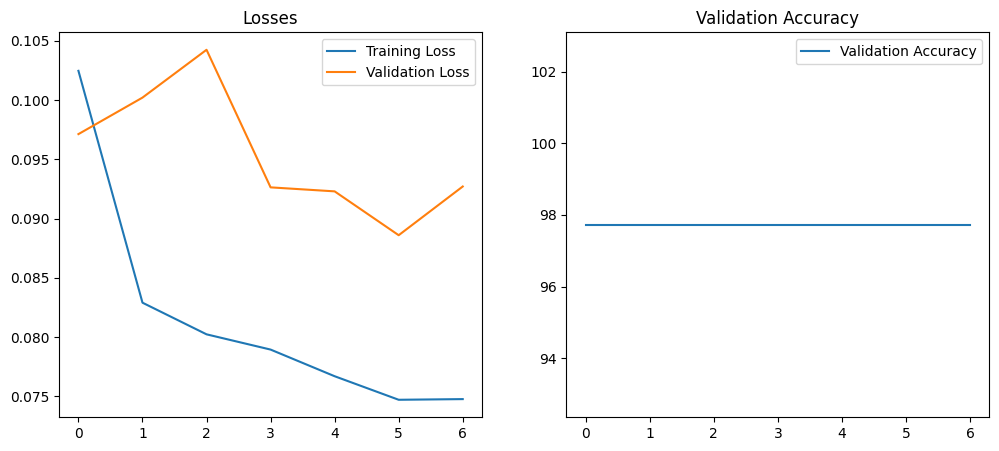

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("Losses")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title("Validation Accuracy")
plt.legend()
plt.show()

In [153]:
# Define the standard deviation of the Gaussian noise
noise_std_dev = 5 # This value can be adjusted based on the desired noise level

# Generate Gaussian noise
noise = np.random.normal(0, noise_std_dev, X_val.shape)

# Add the noise to the validation data
X_val_noise = X_val + noise
X_val_noise_img = X_val_noise.reshape(-1, 1, 50, 50)

X_val_noise_cnn = resize_dataset(X_val_noise_img, new_size=[im_size, im_size])

X_val_noise_cnn = (X_val_noise_cnn - mean) / std

X_val_noise_gs=tf_gs.fit_transform(X_val)
X_val_noise_gs = X_val_noise_gs.reshape(-1, 1, im_size, im_size)

X_val_noise_2d = np.concatenate((X_val_noise_cnn, X_val_noise_gs), axis=1)

X_val_t = torch.tensor(X_val_noise_2d, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

val_dataset = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_dataset, batch_size=32)
train_losses, val_losses, val_accuracies = [], [], []


# Validation
model.eval()
val_loss = 0.0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_loss /= len(val_loader)
accuracy = 100 * correct / total
val_losses.append(val_loss)
val_accuracies.append(accuracy)

print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss:.4f}, Accuracy: {accuracy:.2f}%')



Epoch [7/40], Validation Loss: 0.1193, Accuracy: 97.92%


In [ ]:
train_losses, val_losses, val_accuracies = [], [], []


# Validation
model.eval()
val_loss = 0.0
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_loss /= len(val_loader)
accuracy = 100 * correct / total
val_losses.append(val_loss)
val_accuracies.append(accuracy)

print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss:.4f}, Accuracy: {accuracy:.2f}%')


Epoch [8/40], Validation Loss: 0.0827, Accuracy: 97.90%


## Load Model for noise checking

In [11]:
model.load_state_dict(torch.load('model_best.pth'))

<All keys matched successfully>

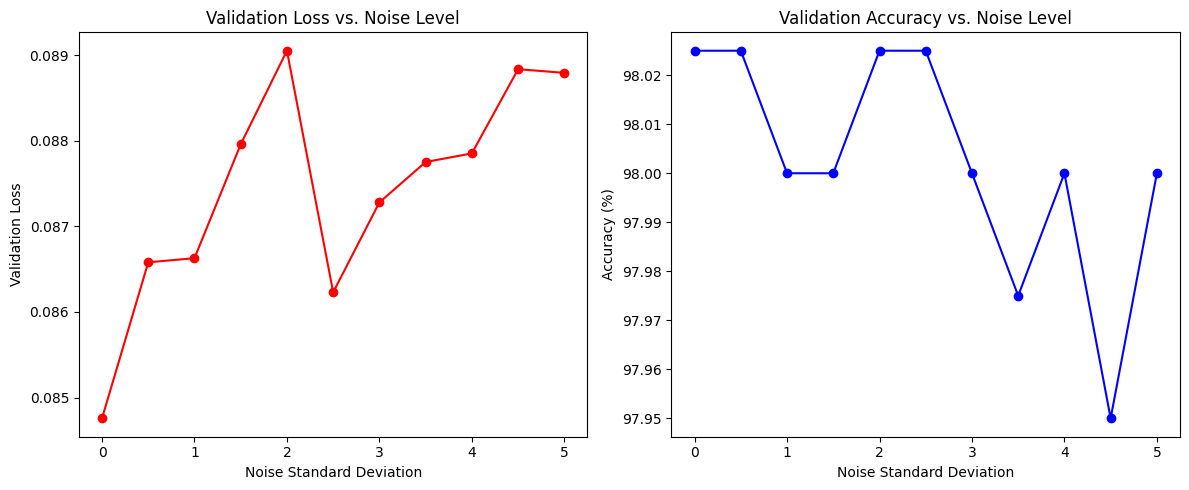

In [12]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Assuming resize_dataset, tf_gs, model, criterion are already defined and initialized
# Also assuming X_val, y_val, mean, std, and im_size are predefined
results = []
val_accuracies = []
val_losses = []
noise_levels = np.arange(0, 5.5, .5)  # From 1 to 10

for noise_std_dev in noise_levels:
    # Generate Gaussian noise
    noise = np.random.normal(0, noise_std_dev, X_val.shape)

    # Add the noise to the validation data
    X_val_noise = X_val + noise
    X_val_noise_img = X_val_noise.reshape(-1, 1, 50, 50)

    X_val_noise_cnn = resize_dataset(X_val_noise_img, new_size=[im_size, im_size])
    X_val_noise_cnn = (X_val_noise_cnn - mean) / std

    X_val_noise_gs = tf_gs.fit_transform(X_val_noise.reshape(-1, 50*50))
    X_val_noise_gs = X_val_noise_gs.reshape(-1, 1, im_size, im_size)

    X_val_noise_2d = np.concatenate((X_val_noise_cnn, X_val_noise_gs), axis=1)

    X_val_t = torch.tensor(X_val_noise_2d, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.long)

    val_dataset = TensorDataset(X_val_t, y_val_t)
    val_loader = DataLoader(val_dataset, batch_size=32)

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    accuracy = 100 * correct / total
    val_losses.append(val_loss)
    val_accuracies.append(accuracy)
    results.append({'noise_std_dev': noise_std_dev, 'val_loss': val_loss, 'val_accuracy': accuracy})

# Plotting the results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(noise_levels, val_losses, marker='o', linestyle='-', color='r')
plt.title('Validation Loss vs. Noise Level')
plt.xlabel('Noise Standard Deviation')
plt.ylabel('Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(noise_levels, val_accuracies, marker='o', linestyle='-', color='b')
plt.title('Validation Accuracy vs. Noise Level')
plt.xlabel('Noise Standard Deviation')
plt.ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()


In [157]:
best_model_path = 'model_best.pth'
torch.save(model.state_dict(), best_model_path)

results_df = pd.DataFrame(results)
results_csv_path = 'validation_results.csv'
results_df.to_csv(results_csv_path, index=False)

print(f'Results saved to {results_csv_path}')

Results saved to validation_results.csv


In [13]:
val_accuracies

[98.025, 98.025, 98.0, 98.0, 98.025, 98.025, 98.0, 97.975, 98.0, 97.95, 98.0]

In [14]:
val_losses

[0.0847578490525484,
 0.08658052954822779,
 0.0866284390501678,
 0.087958833809942,
 0.0890519924648106,
 0.08623017629235982,
 0.08727999288216233,
 0.08775176107883453,
 0.08785265132784843,
 0.08883617103472352,
 0.08879323939979077]